# `02-llm.ipynb`
- 기존 기계적인 워크플로우 -> LLM 을 삽입

```mermaid
flowchart TD

    S[START] --> AS[analyze_sentiment]
    AS --> A{router}
    A -->|positive| P[positive_node]
    A -->|negative| N[negative_node]
    A -->|aggressive| GN[aggressive_node]

    P --> F[make_final_msg]
    N --> F

    GN --> G{block_router}
    G -->|Go warning < 3| F
    G -->|block warning >= 3| B[block_user]

    F --> E[END]
    B --> E
```

1. state -> `warning_count` 를 추가
2. `aggressive_node` 에 도달하면, 무조건 경고 1회 추가
3. `aggressive_node` 이후 경고가 3회를 넘었다면 `block_user` node 로 이동해야함.
4. `block_user` 는 단순히 `차단됨` 이라는 글자만 `return`
---
1. 최초 진입시 `warning_count` 검사 -> 3 이상이면 바로 차단메세지 발송

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# State 정의
from typing import TypedDict, Literal, NotRequired

class TeacherState(TypedDict):
    user_input: str  # 사용자 입력
    sentiment: NotRequired[Literal['positive', 'negative', 'aggressive']]  # 감정 분석
    core_msg:  NotRequired[str]      # 핵심 메세지
    response:  NotRequired[str]      # 최종 답변
    warning_count: NotRequired[int]  # 경고 횟수

In [3]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4.1-mini') 

# LLM 초기화 + 감정분석 Node
def analyze_sentiment(state: TeacherState):
    prompt = f'''
    아래 문장의 감정을 분류.
    아래 3가지 중 1가지 단어로만 판단.
    positive
    negative
    aggressive

    문장: {state['user_input']}
    '''
    result = llm.invoke(prompt)

    return {'sentiment': result.content}  # 바뀐 부분만 return.

In [4]:
# 나머지 노드
import random

def positive_node(state: TeacherState):
    msgs = ['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}


def negative_node(state: TeacherState):
    msgs = ['힘내', '위로', '괜찮']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}


def aggressive_node(state: TeacherState):
    # dict.get(a, b)  -> key a가 있으면, 해당 value. key a가 없으면 b가 나옴
    count = state.get('warning_count', 0) + 1  # state에 'warning_count' 키가 있으면, 그대로 사용. 없으면 0
    return {'core_msg':  '공격적인 표현은 삼가라', 'warning_count': count}


def block_user(state: TeacherState):
    return {'response': '님 차단'}

In [5]:
# 완성 Node
def make_final_msg(state: TeacherState):
    prompt = f'''
    다음 사용자 입력에 맞는 답변을 생성해.
    핵심 키워드를 참조해야해.

    사용자 입력: {state['user_input']}
    핵심 키워드: {state['core_msg']}
    '''
    result = llm.invoke(prompt)
    return {'response': result.content}

In [12]:
def router(state: TeacherState):
    return state['sentiment']  # 단순히 다음 노드를 결정할 문자열만 return


def block_router(state: TeacherState):
    # count = state['warning_count']
    count = state.get('warning_count', 0)
    
    if count >= 3:
        return 'block'
    else:
        return 'gogo'

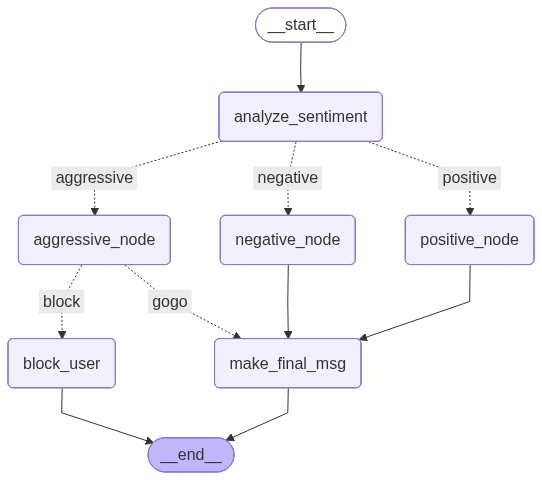

In [13]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TeacherState)
# 노드 등록 (등록 이름과 함수 이름을 맞추기)
graph.add_node('analyze_sentiment', analyze_sentiment)
graph.add_node('positive_node', positive_node)
graph.add_node('negative_node', negative_node)
graph.add_node('aggressive_node', aggressive_node)
graph.add_node('block_user', block_user)
graph.add_node('make_final_msg', make_final_msg)

# 엣지 등록
graph.add_edge(START, 'analyze_sentiment')
graph.add_conditional_edges(
    'analyze_sentiment',
    router,
    {   # router 결과값 -> 다음 노드 이름
        'positive': 'positive_node',
        'negative': 'negative_node',
        'aggressive': 'aggressive_node',
    }
)
graph.add_edge('positive_node', 'make_final_msg')
graph.add_edge('negative_node', 'make_final_msg')
graph.add_conditional_edges(
    'aggressive_node',
    block_router,
    {
        'gogo': 'make_final_msg',
        'block': 'block_user'
    }
)
graph.add_edge('make_final_msg', END)
graph.add_edge('block_user', END)

app = graph.compile()

app

In [14]:
app.invoke({'user_input': '바보', 'warning_count': 0})   # 답변 정상

{'user_input': '바보',
 'sentiment': 'aggressive',
 'core_msg': '공격적인 표현은 삼가라',
 'response': '상대방에게 상처가 될 수 있는 표현은 피하는 것이 좋아요. 서로를 배려하는 마음이 더 좋은 소통을 만들어요.',
 'warning_count': 1}

In [15]:
app.invoke({'user_input': '기분이 좋아', 'warning_count': 3})  # 답변 정상

{'user_input': '기분이 좋아',
 'sentiment': 'positive',
 'core_msg': '멋져',
 'response': '멋져요! 기분이 좋을 때가 가장 행복한 순간이죠. 계속 좋은 기분 유지하세요!',
 'warning_count': 3}

In [16]:
app.invoke({'user_input': '바보', 'warning_count': 3})  # 차단

{'user_input': '바보',
 'sentiment': 'aggressive',
 'core_msg': '공격적인 표현은 삼가라',
 'response': '님 차단',
 'warning_count': 4}